# Purchase Intent Model

## Load Data

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                               RandomForestClassifier, GradientBoostingClassifier)
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score, classification_report, confusion_matrix
import joblib

df = pd.read_csv("../../data/processed/cleaned_users.csv")
df.head()


,Customer_ID,Age,Gender,Occupation,City,Monthly_Income,Annual_Income,Family_Size,Current_Housing_Status,Plot_Budget,...,Expected_Purchase_Timeline,Lead_Source,Previous_Enquiry,Site_Visit,Negotiation_Done,Booking_Done,Purchase_Probability,Purchase_Intent,Purchased,Purchase_Value
0,CUST_20988,21,Male,Unknown,Mumbai,131500.0,1578000,2,Owned Flat/House,7020000.0,...,1-3 years,Google & Social Media Ads,No,No,No,No,0.0639,Low,No,0
1,CUST_16662,29,Male,Real Estate & Construction,Kolkata,43800.0,525600,4,Owned Flat/House,2000000.0,...,1-3 years,Magicbricks / Real Estate Portal,Yes,No,No,No,0.0668,Low,No,0
2,CUST_10543,50,Male,Retail & Commerce,Noida,179000.0,2149200,2,Owned Flat/House,5710000.0,...,0-6 months,Channel Partner / Broker,No,Yes,Yes,Yes,0.9900,High,Yes,5550000
3,CUST_15741,44,Male,Retail & Commerce,Pune,45700.0,548400,4,Living with Parents,2300000.0,...,6-12 months,Print / Newspaper Ad,Yes,No,No,No,0.2293,Low,No,0
4,CUST_16911,38,Male,Business Owner,Ahmedabad,219400.0,2632800,4,Rented,4730000.0,...,0-6 months,Magicbricks / Real Estate Portal,No,Yes,No,No,0.7678,High,Yes,8930000


## Exploratory Analysis

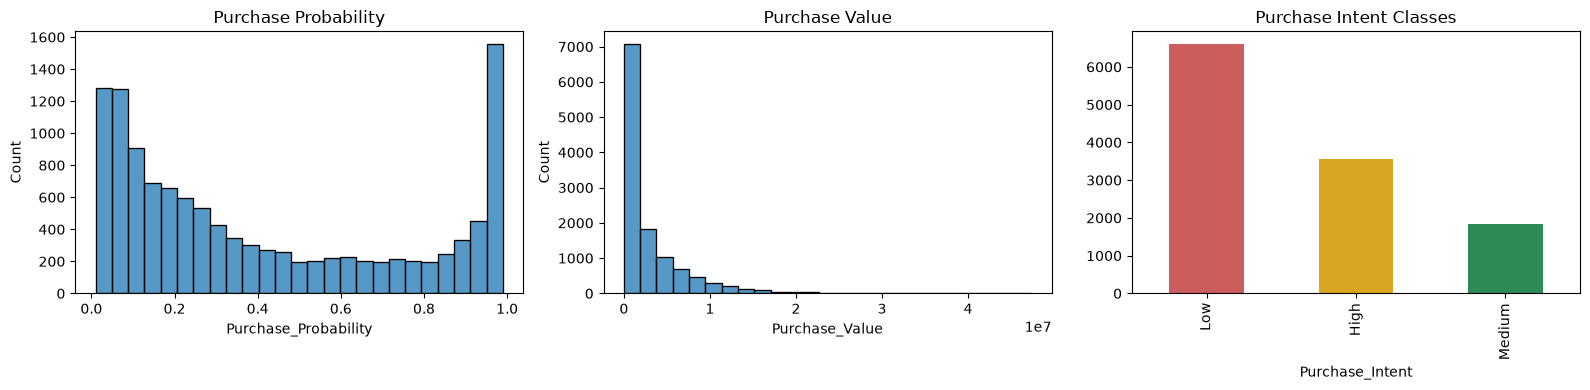

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16,4))
sns.histplot(df["Purchase_Probability"], bins=25, ax=axes[0]); axes[0].set_title("Purchase Probability")
sns.histplot(df["Purchase_Value"], bins=25, ax=axes[1]); axes[1].set_title("Purchase Value")
df["Purchase_Intent"].value_counts().plot(kind="bar", ax=axes[2], color=["indianred","goldenrod","seagreen"])
axes[2].set_title("Purchase Intent Classes")
plt.tight_layout(); plt.show()


In [26]:
df.groupby("Purchase_Intent")["Purchase_Probability"].agg(["min","max","mean"])


,min,max,mean
Purchase_Intent,,,
High,0.65,0.9900,0.893310
Low,0.01,0.3499,0.141577
Medium,0.35,0.6493,0.487692


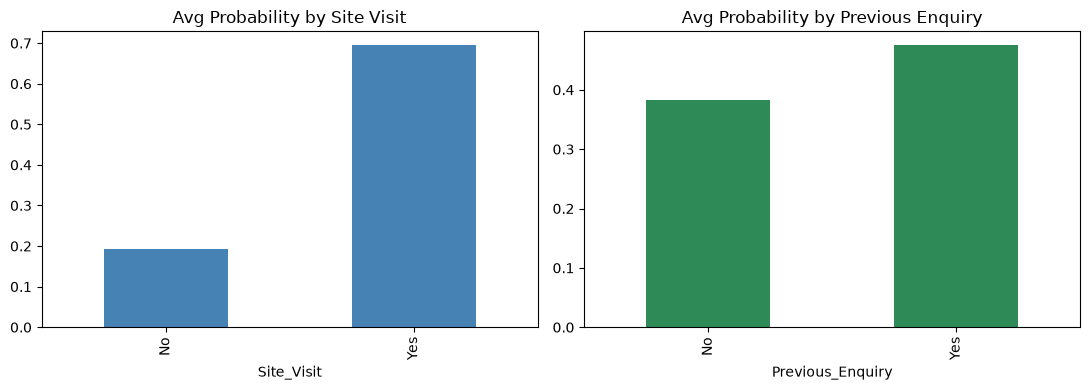

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(11,4))
df.groupby("Site_Visit")["Purchase_Probability"].mean().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Avg Probability by Site Visit")
df.groupby("Previous_Enquiry")["Purchase_Probability"].mean().plot(kind="bar", ax=axes[1], color="seagreen")
axes[1].set_title("Avg Probability by Previous Enquiry")
plt.tight_layout(); plt.show()


## Part 1 - Regression

In [28]:
input_features = ["Age", "Monthly_Income", "Annual_Income", "Family_Size",
                   "Plot_Budget", "Preferred_Plot_Size_SqFt", "Distance_to_City_Center_km",
                   "Gender", "Occupation", "City", "Current_Housing_Status",
                   "Preferred_Location", "Purpose", "Loan_Required",
                   "Expected_Purchase_Timeline", "Lead_Source",
                   "Previous_Enquiry", "Site_Visit", "Negotiation_Done"]
cat_cols = ["Gender", "Occupation", "City", "Current_Housing_Status", "Preferred_Location",
            "Purpose", "Loan_Required", "Expected_Purchase_Timeline", "Lead_Source",
            "Previous_Enquiry", "Site_Visit", "Negotiation_Done"]
target_cols = ["Purchase_Probability", "Purchase_Value"]

X = pd.get_dummies(df[input_features], columns=cat_cols, drop_first=True)
y = df[target_cols].copy()
y.loc[df["Purchased"] == "No", "Purchase_Value"] = 0

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = MinMaxScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)


In [29]:
def evaluate_multi(model, name):
    model.fit(X_train_s, y_train)
    pred = model.predict(X_test_s)
    r2 = r2_score(y_test, pred, multioutput="uniform_average")
    per = r2_score(y_test, pred, multioutput="raw_values")
    print(f"{name}: avg R2={r2:.3f}  (Probability={per[0]:.3f}, Value={per[1]:.3f})")
    return model, r2, per

lr_model, lr_r2, lr_per = evaluate_multi(LinearRegression(), "Linear Regression")

rf_grid = GridSearchCV(RandomForestRegressor(random_state=42), {"n_estimators":[100,200], "max_depth":[10,15]}, cv=2, scoring="r2")
rf_grid.fit(X_train_s, y_train)
rf_model, rf_r2, rf_per = evaluate_multi(rf_grid.best_estimator_, "Tuned Random Forest")

gb_grid = GridSearchCV(MultiOutputRegressor(GradientBoostingRegressor(random_state=42)),
                        {"estimator__n_estimators":[100], "estimator__learning_rate":[0.05,0.1], "estimator__max_depth":[2,3]},
                        cv=2, scoring="r2")
gb_grid.fit(X_train_s, y_train)
gb_model, gb_r2, gb_per = evaluate_multi(gb_grid.best_estimator_, "Tuned Gradient Boosting")

reg_results = pd.DataFrame({
    "Model": ["Linear Regression", "Tuned Random Forest", "Tuned Gradient Boosting"],
    "Purchase_Probability_R2": [lr_per[0], rf_per[0], gb_per[0]],
    "Purchase_Value_R2": [lr_per[1], rf_per[1], gb_per[1]],
    "Avg_R2": [lr_r2, rf_r2, gb_r2],
}).set_index("Model")
reg_results


Linear Regression: avg R2=0.616  (Probability=0.841, Value=0.391)
Tuned Random Forest: avg R2=0.647  (Probability=0.829, Value=0.465)
Tuned Gradient Boosting: avg R2=0.651  (Probability=0.855, Value=0.446)


,Purchase_Probability_R2,Purchase_Value_R2,Avg_R2
Model,,,
Linear Regression,0.840874,0.390810,0.615842
Tuned Random Forest,0.828523,0.465128,0.646825
Tuned Gradient Boosting,0.855329,0.445733,0.650531


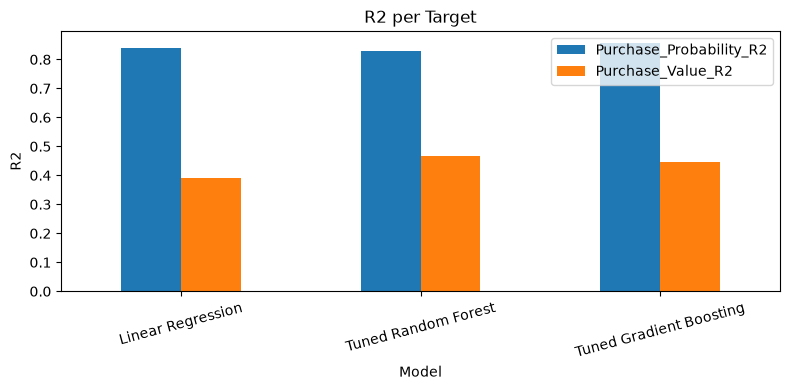

In [30]:
reg_results[["Purchase_Probability_R2", "Purchase_Value_R2"]].plot(kind="bar", figsize=(8,4))
plt.title("R2 per Target"); plt.ylabel("R2"); plt.xticks(rotation=15); plt.tight_layout(); plt.show()


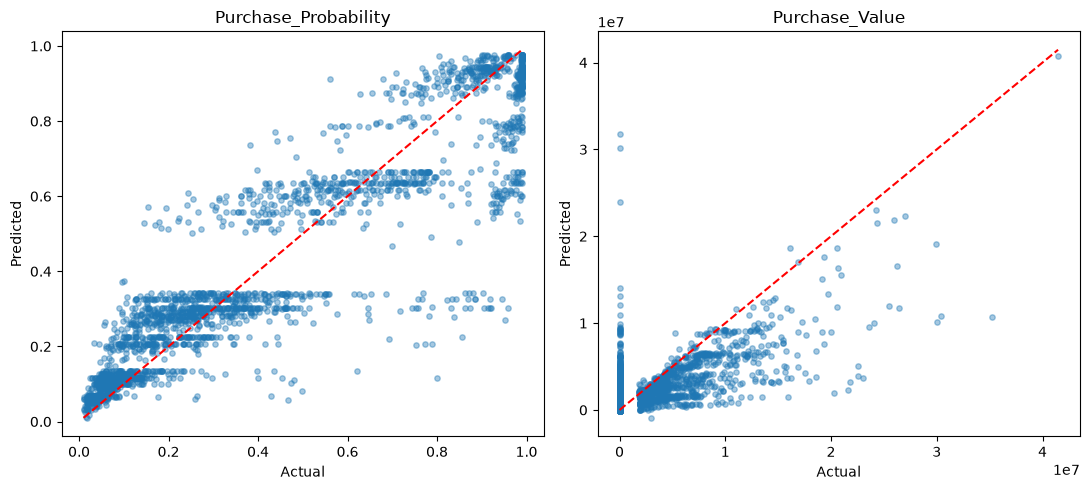

In [31]:
best_reg_name = reg_results["Avg_R2"].idxmax()
best_reg_model = {"Linear Regression": lr_model, "Tuned Random Forest": rf_model, "Tuned Gradient Boosting": gb_model}[best_reg_name]

pred = best_reg_model.predict(X_test_s)
fig, axes = plt.subplots(1, 2, figsize=(11,5))
for ax, col, i in zip(axes, target_cols, range(2)):
    ax.scatter(y_test[col], pred[:, i], alpha=0.4, s=15)
    lims = [y_test[col].min(), y_test[col].max()]
    ax.plot(lims, lims, "r--"); ax.set_title(col); ax.set_xlabel("Actual"); ax.set_ylabel("Predicted")
plt.tight_layout(); plt.show()


In [32]:
joblib.dump(best_reg_model, "../../models/purchase_multi_output_model.pkl")
joblib.dump(scaler, "../../models/purchase_reg_scaler.pkl")
joblib.dump(list(X.columns), "../../models/purchase_reg_columns.pkl")
joblib.dump(target_cols, "../../models/purchase_reg_targets.pkl")
print("Saved:", best_reg_name)


Saved: Tuned Gradient Boosting


## Part 2 - Classification

In [33]:
Xc = pd.get_dummies(df[input_features], columns=cat_cols, drop_first=True)
yc = df["Purchase_Intent"]

Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc, yc, test_size=0.2, random_state=42, stratify=yc)
clf_scaler = MinMaxScaler()
Xc_train_s = clf_scaler.fit_transform(Xc_train)
Xc_test_s = clf_scaler.transform(Xc_test)

def evaluate_clf(model, name):
    model.fit(Xc_train_s, yc_train)
    pred = model.predict(Xc_test_s)
    acc = accuracy_score(yc_test, pred)
    print(f"{name}: accuracy={acc:.3f}")
    return model, acc, pred

lr_clf, lr_acc, _ = evaluate_clf(LogisticRegression(max_iter=1000, class_weight="balanced"), "Logistic Regression")
gb_clf, gb_acc, gb_pred = evaluate_clf(GradientBoostingClassifier(n_estimators=200, random_state=42), "Gradient Boosting")

rf_grid = GridSearchCV(RandomForestClassifier(random_state=42, class_weight="balanced"),
                        {"n_estimators":[100,200], "max_depth":[8,15]}, cv=2, scoring="f1_macro")
rf_grid.fit(Xc_train_s, yc_train)
rf_clf, rf_acc, rf_pred = evaluate_clf(rf_grid.best_estimator_, "Tuned Random Forest")

clf_results = pd.DataFrame({"Model": ["Logistic Regression","Gradient Boosting","Tuned Random Forest"],
                             "Accuracy": [lr_acc, gb_acc, rf_acc]}).set_index("Model")
clf_results


Logistic Regression: accuracy=0.781
Gradient Boosting: accuracy=0.840
Tuned Random Forest: accuracy=0.818


,Accuracy
Model,
Logistic Regression,0.781250
Gradient Boosting,0.840000
Tuned Random Forest,0.818333


              precision    recall  f1-score   support

        High       0.85      0.86      0.85       710
         Low       0.89      0.95      0.92      1322
      Medium       0.55      0.40      0.46       368

    accuracy                           0.84      2400
   macro avg       0.76      0.74      0.75      2400
weighted avg       0.83      0.84      0.83      2400



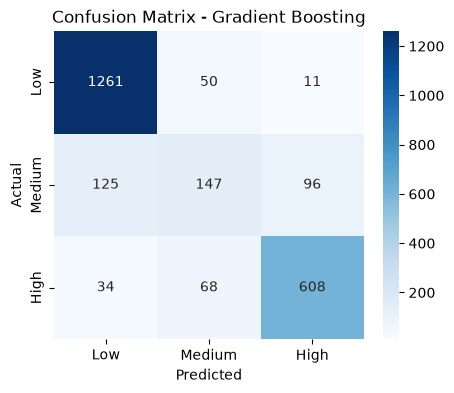

In [34]:
best_clf_name = clf_results["Accuracy"].idxmax()
best_clf_model, best_pred = {"Logistic Regression": (lr_clf, None), "Gradient Boosting": (gb_clf, gb_pred),
                              "Tuned Random Forest": (rf_clf, rf_pred)}[best_clf_name]
print(classification_report(yc_test, best_clf_model.predict(Xc_test_s)))

cm = confusion_matrix(yc_test, best_clf_model.predict(Xc_test_s), labels=["Low","Medium","High"])
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Low","Medium","High"], yticklabels=["Low","Medium","High"])
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title(f"Confusion Matrix - {best_clf_name}")
plt.show()


In [35]:
joblib.dump(best_clf_model, "../../models/purchase_intent_classifier.pkl")
joblib.dump(clf_scaler, "../../models/purchase_intent_clf_scaler.pkl")
joblib.dump(list(Xc.columns), "../../models/purchase_intent_clf_columns.pkl")
print("Saved:", best_clf_name)


Saved: Gradient Boosting
